# Healthcare Fraud Detection with PyTorch

## Overview
This project builds a deep learning pipeline (PyTorch) to flag potentially fraudulent
healthcare insurance claims — a binary classification task on imbalanced tabular data.

## Dataset
Healthcare Fraud Detection dataset (Kaggle, ~10,000 claims). Each row is a claim with
patient, provider, financial, and temporal attributes; the target `is_fraud` is highly
imbalanced (~8% positive).

## Approach
- **Preprocessing:** drop rows with missing values, remove high-cardinality identifiers
  and post-decision leakage features (`claim_status`, `approved_amount`), one-hot encode
  categoricals, Yeo-Johnson scale numerics, and cyclical-encode date features — all fit on
  the training set only to avoid leakage.
- **Model:** a feed-forward neural network (Linear + BatchNorm + ReLU + Dropout) trained
  with `BCEWithLogitsLoss` and a positive-class weight to handle imbalance.
- **Training:** stratified 60/20/20 split, early stopping on validation loss, and a grid
  search over learning rate, dropout, and class-weighting.
- **Evaluation:** PR-AUC as the primary metric (suited to imbalance), plus ROC-AUC and a
  decision threshold tuned on the validation set to maximize recall subject to precision ≥ 0.5.
- **Explainability:** SHAP (DeepExplainer) to interpret feature contributions.

## Results
Post-decision leakage features (`claim_status`, `approved_amount`) are dropped before
training, so the scores reflect a realistic operating point. On the held-out test set,
PR-AUC ≈ 0.68 against a 0.08 positive-rate baseline (~8× lift) and ROC-AUC ≈ 0.96. At the
chosen threshold the model catches ~80% of fraud (recall 0.80) at 0.50 precision — a
deliberate trade-off that favors catching fraud over minimizing false alarms. The focus
here is a correct, leak-free pipeline and an honest result, not an inflated headline score.

# Import Library

In [26]:
import kagglehub
from kagglehub import KaggleDatasetAdapter as kda
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, precision_recall_curve, roc_auc_score, roc_curve

from feature_engine.creation import CyclicalFeatures

import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn

from itertools import product

import shap


# Import Dataset and Cleaning

In [2]:
df = kagglehub.dataset_load(
    kda.PANDAS
    , 'nudratabbas/healthcare-fraud-detection-dataset'
    , 'healthcare_fraud_detection.csv'
)

df.columns = df.columns.str.lower()

df.sample(5)


,provider_id,claim_id,patient_age,patient_gender,diagnosis_code,procedure_code,claim_amount,approved_amount,insurance_type,claim_submission_date,days_between_service_and_claim,number_of_claims_per_provider_monthly,provider_specialty,patient_state,claim_status,is_fraud,length_of_stay,visit_type,chronic_condition_flag,prior_visits_12m
8912,P0036,C0008912,45,Male,E78.5,36415,750.25,571.51,Medicare,2021-08-14,2,77,NaN,GA,Approved,0,0,Emergency,1,5.0
8790,P0057,C0008790,70,Female,K21.9,93000,1771.00,1431.91,Private,2024-11-19,16,66,Internal Medicine,IL,Rejected,0,2,Emergency,0,3.0
7145,P0083,C0007145,9,Male,I10,93000,584.92,558.04,Medicare,2022-05-13,7,57,Neurology,IL,Pending,0,3,Outpatient,0,3.0
704,P0010,C0000704,68,Female,J18.9,36415,259.32,195.17,Private,2022-10-23,4,54,Internal Medicine,CA,Rejected,0,3,Emergency,0,0.0
5826,P0139,C0005826,77,Male,K21.9,99213,363.52,316.40,Private,2021-12-21,23,71,General Practice,CA,Approved,0,2,Inpatient,0,0.0


In [3]:
# Recheck data type
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   provider_id                            10000 non-null  str    
 1   claim_id                               10000 non-null  str    
 2   patient_age                            10000 non-null  int64  
 3   patient_gender                         10000 non-null  str    
 4   diagnosis_code                         10000 non-null  str    
 5   procedure_code                         10000 non-null  int64  
 6   claim_amount                           10000 non-null  float64
 7   approved_amount                        10000 non-null  float64
 8   insurance_type                         9650 non-null   str    
 9   claim_submission_date                  10000 non-null  str    
 10  days_between_service_and_claim         10000 non-null  int64  
 11  number_of_clai

Need to change data type in claim_submission_date from str to datetime

In [4]:
df['claim_submission_date'] = pd.to_datetime(df['claim_submission_date'])
df['chronic_condition_flag'] = df['chronic_condition_flag'].astype('str')


In [5]:
df.isna().sum()


provider_id                                0
claim_id                                   0
patient_age                                0
patient_gender                             0
diagnosis_code                             0
procedure_code                             0
claim_amount                               0
approved_amount                            0
insurance_type                           350
claim_submission_date                      0
days_between_service_and_claim             0
number_of_claims_per_provider_monthly      0
provider_specialty                       350
patient_state                              0
claim_status                               0
is_fraud                                   0
length_of_stay                             0
visit_type                                 0
chronic_condition_flag                     0
prior_visits_12m                         350
dtype: int64

In [6]:
print('no. of null row:', len(df[df.isna().any(axis=1)]))
print('no. of row after remove null row:', len(df.dropna()))


no. of null row: 1011
no. of row after remove null row: 8989


I decide to remove null row

In [7]:
df = df.dropna()
df.isna().sum()


provider_id                              0
claim_id                                 0
patient_age                              0
patient_gender                           0
diagnosis_code                           0
procedure_code                           0
claim_amount                             0
approved_amount                          0
insurance_type                           0
claim_submission_date                    0
days_between_service_and_claim           0
number_of_claims_per_provider_monthly    0
provider_specialty                       0
patient_state                            0
claim_status                             0
is_fraud                                 0
length_of_stay                           0
visit_type                               0
chronic_condition_flag                   0
prior_visits_12m                         0
dtype: int64

In [8]:
# Remove some column no need to use
df = df.drop(columns=['provider_id','diagnosis_code','claim_id','procedure_code'])

# Remove `claim_status` and `approved_amount` features, It's post-decision
df = df.drop(columns=['claim_status','approved_amount'])

df.info()


<class 'pandas.DataFrame'>
Index: 8989 entries, 0 to 9998
Data columns (total 14 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   patient_age                            8989 non-null   int64         
 1   patient_gender                         8989 non-null   str           
 2   claim_amount                           8989 non-null   float64       
 3   insurance_type                         8989 non-null   str           
 4   claim_submission_date                  8989 non-null   datetime64[us]
 5   days_between_service_and_claim         8989 non-null   int64         
 6   number_of_claims_per_provider_monthly  8989 non-null   int64         
 7   provider_specialty                     8989 non-null   str           
 8   patient_state                          8989 non-null   str           
 9   is_fraud                               8989 non-null   int64         
 10  leng

# Feature Engineering

## Create New Feature

In [9]:
df['weekend'] = pd.to_datetime(df['claim_submission_date']).dt.dayofweek.apply(lambda x: 'yes' if x >=5 else 'no')
df['dayofweek'] = pd.to_datetime(df['claim_submission_date']).dt.dayofweek
df['dayofmonth'] = pd.to_datetime(df['claim_submission_date']).dt.day
df['month'] = pd.to_datetime(df['claim_submission_date']).dt.month

df[['claim_submission_date','weekend','dayofweek','dayofmonth','month']]


,claim_submission_date,weekend,dayofweek,dayofmonth,month
0,2024-09-01,yes,6,1,9
1,2022-09-05,no,0,5,9
2,2022-04-11,no,0,11,4
3,2023-10-11,no,2,11,10
4,2023-09-05,no,1,5,9
...,...,...,...,...,...
9994,2024-01-22,no,0,22,1
9995,2024-09-24,no,1,24,9
9996,2023-01-04,no,2,4,1
9997,2024-06-30,yes,6,30,6


In [10]:
cyclical = CyclicalFeatures(
    variables=['dayofweek', 'dayofmonth','month'],
    drop_original=True,
    max_values={
        'dayofweek': 7,
        'dayofmonth': 31,
        'month':12
    }
)
df = cyclical.fit_transform(df)

df


,patient_age,patient_gender,claim_amount,insurance_type,claim_submission_date,days_between_service_and_claim,number_of_claims_per_provider_monthly,provider_specialty,patient_state,is_fraud,...,visit_type,chronic_condition_flag,prior_visits_12m,weekend,dayofweek_sin,dayofweek_cos,dayofmonth_sin,dayofmonth_cos,month_sin,month_cos
0,37,Male,443.51,Medicaid,2024-09-01,13,70,Cardiology,NY,0,...,Outpatient,1,2.0,yes,-0.781831,0.623490,0.201299,0.979530,-1.000000e+00,-1.836970e-16
1,21,Female,467.50,Self-Pay,2022-09-05,5,62,General Practice,IL,0,...,Inpatient,1,2.0,no,0.000000,1.000000,0.848644,0.528964,-1.000000e+00,-1.836970e-16
2,78,Female,591.69,Medicaid,2022-04-11,29,60,Cardiology,IL,0,...,Inpatient,1,3.0,no,0.000000,1.000000,0.790776,-0.612106,8.660254e-01,-5.000000e-01
3,65,Male,235.15,Private,2023-10-11,22,70,General Practice,TX,0,...,Emergency,0,5.0,no,0.974928,-0.222521,0.790776,-0.612106,-8.660254e-01,5.000000e-01
4,36,Male,487.96,Private,2023-09-05,21,67,Pulmonology,PA,0,...,Inpatient,0,4.0,no,0.781831,0.623490,0.848644,0.528964,-1.000000e+00,-1.836970e-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9994,50,Female,395.58,Medicaid,2024-01-22,18,82,Pulmonology,CA,0,...,Outpatient,1,3.0,no,0.000000,1.000000,-0.968077,-0.250653,5.000000e-01,8.660254e-01
9995,79,Male,590.19,Private,2024-09-24,2,115,Internal Medicine,PA,1,...,Inpatient,1,3.0,no,0.781831,0.623490,-0.988468,0.151428,-1.000000e+00,-1.836970e-16
9996,66,Male,219.73,Self-Pay,2023-01-04,6,73,Orthopedics,IL,0,...,Inpatient,0,6.0,no,0.974928,-0.222521,0.724793,0.688967,5.000000e-01,8.660254e-01
9997,43,Female,505.24,Medicare,2024-06-30,6,59,Neurology,OH,0,...,Emergency,1,0.0,yes,-0.781831,0.623490,-0.201299,0.979530,1.224647e-16,-1.000000e+00


## Split Dataset

In [11]:
# Split Dataset
x = df.drop(['is_fraud'], axis=1)
y = df['is_fraud']

# 60/20/20 train/val/test, stratified on the imbalanced target
x_train, x_temp, y_train, y_temp = train_test_split(
    x, y, test_size=0.40, random_state=1, stratify=y)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.50, random_state=1, stratify=y_temp)

print('train:', x_train.shape[0], '| val:', x_val.shape[0], '| test:', x_test.shape[0])


train: 5393 | val: 1798 | test: 1798


## Encoding


In [12]:
# Separate featrue type
nominal_feature = ['patient_gender','insurance_type','provider_specialty','patient_state','visit_type','chronic_condition_flag','weekend']
number_feature = ['patient_age','claim_amount','length_of_stay','days_between_service_and_claim','number_of_claims_per_provider_monthly','prior_visits_12m']
pass_feature = ['dayofweek_sin','dayofweek_cos','dayofmonth_sin','dayofmonth_cos','month_sin','month_cos']

# Pipeline number feature
num_pipe = Pipeline([
    ('yj', PowerTransformer(method='yeo-johnson', standardize=True))
])

# Create Column Transform Step
preprocessor = ColumnTransformer(
    transformers=[
        ('nom', OneHotEncoder(handle_unknown='ignore'), nominal_feature)
        , ('num', num_pipe, number_feature)
        , ('pass', 'passthrough', pass_feature)
    ]
)
    
encoder_pipeline =  Pipeline([
    ('preprocessor', preprocessor)
])

# Fit on train only; val/test are transformed with the fitted pipeline (no leakage)
x_train_transformed = encoder_pipeline.fit_transform(x_train)
x_val_transformed   = encoder_pipeline.transform(x_val)
x_test_transformed  = encoder_pipeline.transform(x_test)


# Build Model

## Prepare Dataset

In [13]:
# Convert all dataset to tensor
x_train_tensor = torch.tensor(x_train_transformed, dtype=torch.float32)
x_val_tensor   = torch.tensor(x_val_transformed, dtype=torch.float32)
x_test_tensor  = torch.tensor(x_test_transformed, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
y_val_tensor   = torch.tensor(y_val.values, dtype=torch.float32).view(-1,1)
y_test_tensor  = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)


In [14]:
# Package x and y
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(x_val_tensor, y_val_tensor)
test_dataset  = TensorDataset(x_test_tensor, y_test_tensor)

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(dataset=val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)


## Build Neural Network

In [15]:

class FraudDetectionNet(nn.Module):
    def __init__(self, input_features, hidden1=64, hidden2=32, dropout1=0.3, dropout2=0.2):
        super().__init__()

        self.network = nn.Sequential(
            # Hidden Layer 1
            nn.Linear(input_features, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(dropout1),

            # Hidden Layer 2
            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(dropout2),

            # Output Layer
            nn.Linear(hidden2, 1)
        )

    def forward(self, x):
        return self.network(x)

num_features = x_train_transformed.shape[1]

# Class-imbalance weight for the positive (fraud) class.
# mode='full' -> neg/pos (~11, max recall); mode='sqrt' -> sqrt(neg/pos) (~3.3, milder)
def make_pos_weight(y_tensor, mode='full'):
    num_pos = y_tensor.sum()
    num_neg = len(y_tensor) - num_pos
    ratio = num_neg / num_pos
    return ratio if mode == 'full' else ratio.sqrt()


## Train Function

In [16]:
# Train one model with early stopping on validation loss; restore best-on-val weights
def train_model(hparams, epochs=100, patience=10):
    torch.manual_seed(1)
    model = FraudDetectionNet(
        num_features,
        dropout1=hparams['dropout1'],
        dropout2=hparams['dropout2'],
    )
    pos_weight = make_pos_weight(y_train_tensor, hparams['pos_weight_mode'])
    cost_function = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=hparams['lr'])

    best_val, best_state, no_improve = float('inf'), None, 0

    for epoch in range(epochs):
        model.train()
        for bx, by in train_loader:
            optimizer.zero_grad()
            loss = cost_function(model(bx), by)
            loss.backward()
            optimizer.step()
            
        # Validation loss (the tuning/early-stopping signal — test set is never touched here)
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for bx, by in val_loader:
                val_loss += cost_function(model(bx), by).item()
        val_loss /= len(val_loader)

        if val_loss < best_val:
            best_val, no_improve = val_loss, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve == patience:
                break

    model.load_state_dict(best_state)
    return model


# Collect predicted probabilities + labels for any loader
def predict_proba(model, loader):
    model.eval()
    probs, labels = [], []
    with torch.no_grad():
        for bx, by in loader:
            probs.extend(torch.sigmoid(model(bx)).numpy())
            labels.extend(by.numpy())
    return np.array(probs), np.array(labels)


## Hyperparameter Tuning

Grid search over `lr`, `pos_weight` strategy, and `dropout`. Each config is trained on **train**,
early-stopped on **val**, and scored by **validation PR-AUC** (the right metric for this imbalance).
The **test set is never used here.**

In [17]:
grid = {
    'lr': [1e-4, 5e-4],
    'pos_weight_mode': ['full', 'sqrt'],
    'dropout1': [0.3, 0.5],
}

results, best = [], None
for lr, pwm, d1 in product(grid['lr'], grid['pos_weight_mode'], grid['dropout1']):
    hp = {'lr': lr, 'pos_weight_mode': pwm, 'dropout1': d1, 'dropout2': max(d1 - 0.1, 0.1)}

    m = train_model(hp)
    val_probs, val_labels = predict_proba(m, val_loader)
    val_ap = average_precision_score(val_labels, val_probs)

    results.append({**hp, 'val_pr_auc': val_ap})
    
    if best is None or val_ap > best['val_pr_auc']:
        best = {'hp': hp, 'val_pr_auc': val_ap, 'model': m}

    print(f"lr={lr:.4f} pos_weight={pwm} dropout={d1} -> val PR-AUC={val_ap:.4f}")

results_df = pd.DataFrame(results).sort_values('val_pr_auc', ascending=False).reset_index()
results_df


lr=0.0001 pos_weight=full dropout=0.3 -> val PR-AUC=0.6937
lr=0.0001 pos_weight=full dropout=0.5 -> val PR-AUC=0.6998
lr=0.0001 pos_weight=sqrt dropout=0.3 -> val PR-AUC=0.6881
lr=0.0001 pos_weight=sqrt dropout=0.5 -> val PR-AUC=0.6957
lr=0.0005 pos_weight=full dropout=0.3 -> val PR-AUC=0.6946
lr=0.0005 pos_weight=full dropout=0.5 -> val PR-AUC=0.6986
lr=0.0005 pos_weight=sqrt dropout=0.3 -> val PR-AUC=0.6812
lr=0.0005 pos_weight=sqrt dropout=0.5 -> val PR-AUC=0.6956


,index,lr,pos_weight_mode,dropout1,dropout2,val_pr_auc
0,1,0.0001,full,0.5,0.4,0.699840
1,5,0.0005,full,0.5,0.4,0.698554
2,3,0.0001,sqrt,0.5,0.4,0.695740
3,7,0.0005,sqrt,0.5,0.4,0.695631
4,4,0.0005,full,0.3,0.2,0.694629
5,0,0.0001,full,0.3,0.2,0.693712
6,2,0.0001,sqrt,0.3,0.2,0.688084
7,6,0.0005,sqrt,0.3,0.2,0.681184


## Select Best Model & Tune Threshold

In [18]:
# Best model from the search -> assign to `model` so downstream cells keep working
model = best['model']
print('Best hyperparameters  :', best['hp'])
print('Best validation PR-AUC:', round(best['val_pr_auc'], 4))

# Tune the decision threshold on validation (maximize Recall subject to Precision >= 0.5)
val_probs, val_labels = predict_proba(model, val_loader)
prec, rec, thr = precision_recall_curve(val_labels, val_probs)

min_precision = 0.5
mask = prec[:-1] >= min_precision
valid_thr = thr[mask]
valid_rec = rec[:-1][mask]
best_threshold = float(valid_thr[np.argmax(valid_rec)])
print('Tuned decision threshold (from val):', round(best_threshold, 3))


Best hyperparameters  : {'lr': 0.0001, 'pos_weight_mode': 'full', 'dropout1': 0.5, 'dropout2': 0.4}
Best validation PR-AUC: 0.6998
Tuned decision threshold (from val): 0.764


## Testing Loop

In [19]:
model.eval()

all_preds = []
all_labels = []
all_probs = [] # raw probabilities for PR-AUC

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        logits = model(batch_x)
        probs = torch.sigmoid(logits)
        predictions = (probs > best_threshold).float()   # threshold tuned on val
        all_preds.extend(predictions.numpy())
        all_labels.extend(batch_y.numpy())
        all_probs.extend(probs.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)


# Evaluate Model

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.93      0.95      1647
         1.0       0.50      0.80      0.62       151

    accuracy                           0.92      1798
   macro avg       0.74      0.86      0.79      1798
weighted avg       0.94      0.92      0.93      1798



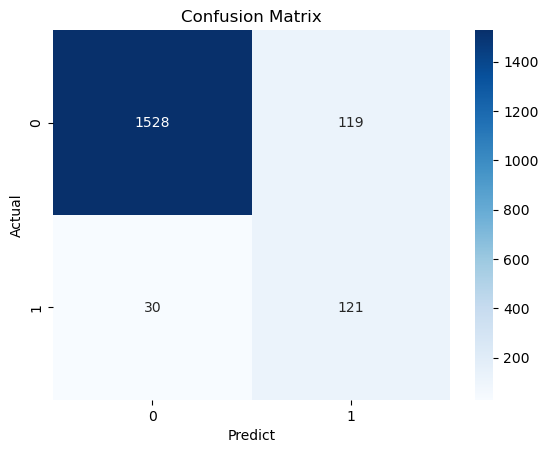

In [20]:
print("Classification Report:")
print(classification_report(all_labels, all_preds))

sns.heatmap(
    confusion_matrix(all_labels, all_preds)
    , cmap='Blues'
    , annot=True
    , fmt='d'
)
plt.xlabel('Predict')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


## PR-AUC (Average Precision)

PR-AUC (Average Precision): 0.6786
Baseline (positive rate)  : 0.0840


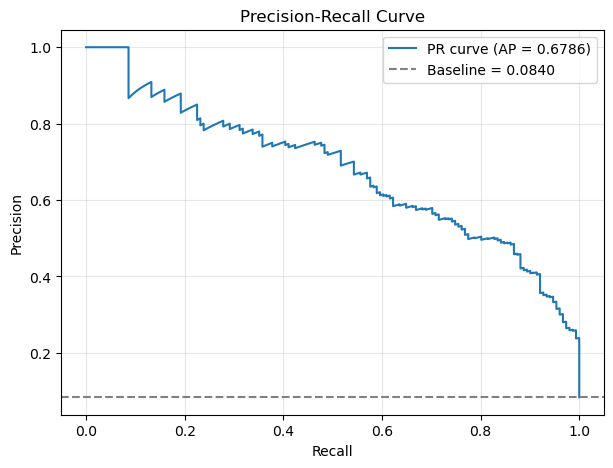

In [21]:
ap = average_precision_score(all_labels, all_probs)
baseline = all_labels.mean()

print(f"PR-AUC (Average Precision): {ap:.4f}")
print(f"Baseline (positive rate)  : {baseline:.4f}")

precision, recall, thresholds = precision_recall_curve(all_labels, all_probs)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f'PR curve (AP = {ap:.4f})')
plt.axhline(baseline, linestyle='--', color='gray',label=f'Baseline = {baseline:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## ROC Curve / AUC

ROC-AUC: 0.9564


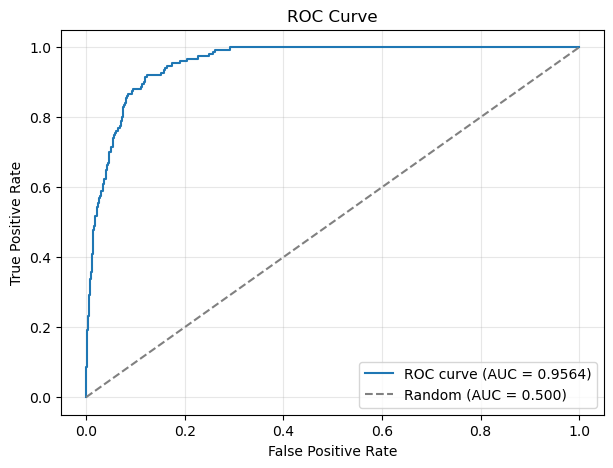

In [22]:
# ROC-AUC — area under the True Positive Rate vs False Positive Rate curve
roc_auc = roc_auc_score(all_labels, all_probs)
print(f"ROC-AUC: {roc_auc:.4f}")

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray',
         label='Random (AUC = 0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Feature Importance

In [23]:
model.eval()
np.random.seed(1)

# Readable feature names from the preprocessing pipeline
# (OneHotEncoder expands nominal cols -> strip the 'nom__'/'num__'/'pass__' prefix)
feature_names = encoder_pipeline.get_feature_names_out()
feature_names = [name.split('__', 1)[-1] for name in feature_names]

# Background = small sample of training data (reference distribution for SHAP)
bg_idx = np.random.choice(x_train_tensor.shape[0], size=100, replace=False)
background = x_train_tensor[bg_idx]

# Subset of the test set to explain (keep small for speed)
explain_idx = np.random.choice(x_test_tensor.shape[0], size=500, replace=False)
x_explain = x_test_tensor[explain_idx]

# DeepExplainer: DeepLIFT-style attribution for neural networks
explainer = shap.DeepExplainer(model, background)
shap_values = explainer.shap_values(x_explain, check_additivity=False)

# Normalize shape -> (n_samples, n_features)
if isinstance(shap_values, list):
    shap_values = shap_values[0]
shap_values = np.array(shap_values)
if shap_values.ndim == 3:
    shap_values = shap_values.squeeze()

print("shap_values shape:", shap_values.shape)


shap_values shape: (500, 39)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_38072\3083309059.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


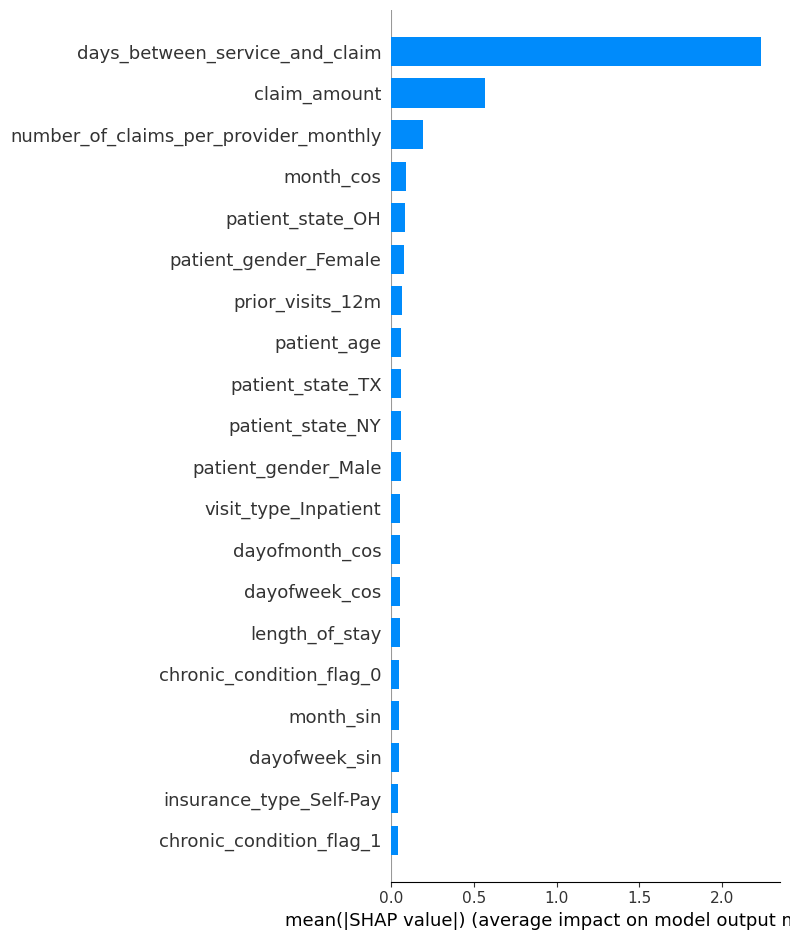

In [24]:
# Global feature importance: mean(|SHAP|) per feature (bar chart)
shap.summary_plot(
    shap_values,
    x_explain.numpy(),
    feature_names=feature_names,
    plot_type='bar'
)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_38072\2245851249.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


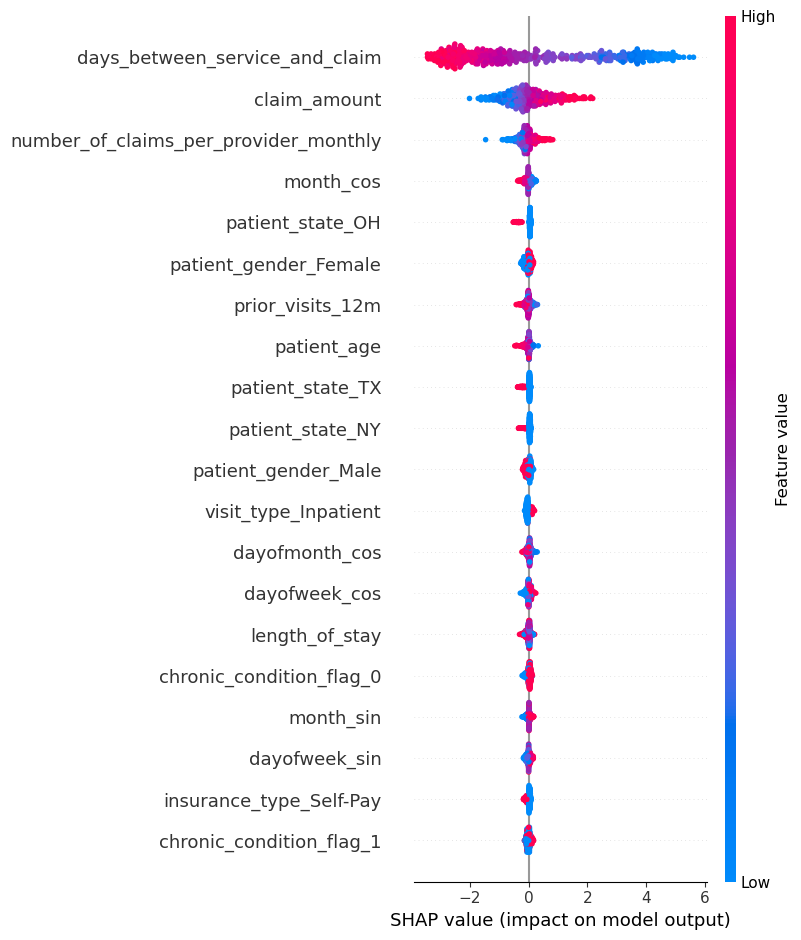

In [25]:
# Beeswarm: shows direction + magnitude of each feature's effect on the fraud logit
# (red = high feature value, blue = low; right = pushes toward fraud)
shap.summary_plot(
    shap_values,
    x_explain.numpy(),
    feature_names=feature_names
)


## Limitations & Reflection

- **Leakage removed up front.** `claim_status` and `approved_amount` are outcomes known only *after* a claim is adjudicated, so they would not be available at prediction time in production. Both were dropped before training to keep the task realistic.
- **Realistic — not inflated — performance.** Without those post-decision features, test PR-AUC ≈ 0.68 (≈ 8× the 0.08 baseline) and ROC-AUC ≈ 0.96. At the tuned threshold the model catches ~80% of fraud (recall 0.80) at 0.50 precision — a deliberate trade-off favoring recall, since missed fraud is usually costlier than a false alarm sent for manual review.
- **Synthetic data caveat.** This is a *synthetic* Kaggle dataset; its patterns are cleaner and more separable than real bank/insurance data, where the signal would be noisier and harder to capture.
- **What I would do on real data:** use a time-based split (train on earlier periods, test on later), engineer provider- and patient-level aggregate features, and benchmark the network against simpler baselines (Logistic Regression / XGBoost).
- **Focus of this project:** building a correct, leak-free PyTorch *pipeline* — stratified split, class-imbalance handling, PR-AUC, threshold tuning, early stopping, and SHAP explainability — and reporting an honest result rather than chasing the headline score.